# 01. Introduction

**Project:** Gym Customer Churn Prediction

Notebook này xây dựng các baseline machine learning models cho bài toán dự đoán khách hàng rời bỏ phòng gym. Mục tiêu là thiết lập một workflow modeling sạch, reproducible và dễ mở rộng trước khi thực hiện feature engineering, xử lý imbalance nâng cao hoặc tuning hyperparameters.

Baseline rất quan trọng vì:
- Tạo mốc so sánh ban đầu cho các notebook sau.
- Giúp đánh giá dữ liệu gốc đã có tín hiệu dự đoán churn mạnh hay chưa.
- Giúp so sánh trade-off giữa model dễ giải thích và model có performance cao.
- Tránh tối ưu quá sớm khi chưa hiểu rõ hành vi của mô hình.

Trong notebook này, ta **chưa làm feature engineering**, **chưa dùng SMOTE**, **chưa tuning chuyên sâu**, và chỉ dùng preprocessing tối thiểu.


# 02. Import Libraries

Import các thư viện cần thiết cho data handling, visualization, modeling pipeline, evaluation metrics và model persistence.


In [16]:
import os
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    ConfusionMatrixDisplay,
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
)
from sklearn.svm import SVC

try:
    from xgboost import XGBClassifier
except ImportError:
    XGBClassifier = None
    print("xgboost is not installed. XGBoost will be skipped.")

try:
    from lightgbm import LGBMClassifier
except ImportError:
    LGBMClassifier = None
    print("lightgbm is not installed. LightGBM will be skipped.")

try:
    from catboost import CatBoostClassifier
except ImportError:
    CatBoostClassifier = None
    print("catboost is not installed. CatBoost will be skipped.")

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TARGET_COL = "Churn"

sns.set_theme(style="whitegrid", context="notebook", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["axes.unicode_minus"] = False

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


# 03. Load Dataset

Load dataset gốc, kiểm tra kích thước, xem nhanh dữ liệu và phân phối target `Churn`.


Project: Gym Customer Churn Prediction
Project root: D:\UIT SUBJECTS\Nam 2 - hoc ki 2 - Machine Learning\DoAn - GymCustomers and Churn
Data path: D:\UIT SUBJECTS\Nam 2 - hoc ki 2 - Machine Learning\DoAn - GymCustomers and Churn\Data\gym_churn_us.csv
Dataset shape: 4,000 rows x 14 columns


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.2275,5.0000,3,0.0204,0.0000,0
1,0,1,0,0,1,12,1,31,113.2029,12.0000,7,1.9229,1.9102,0
2,0,1,1,0,1,1,0,28,129.4485,1.0000,2,1.8591,1.7365,0
3,0,1,1,1,1,12,1,33,62.6699,12.0000,2,3.2056,3.3572,0
4,1,1,1,1,1,1,0,26,198.3623,1.0000,3,1.1139,1.1201,0


,count,percentage
Churn,,
0,2939,73.4700
1,1061,26.5200


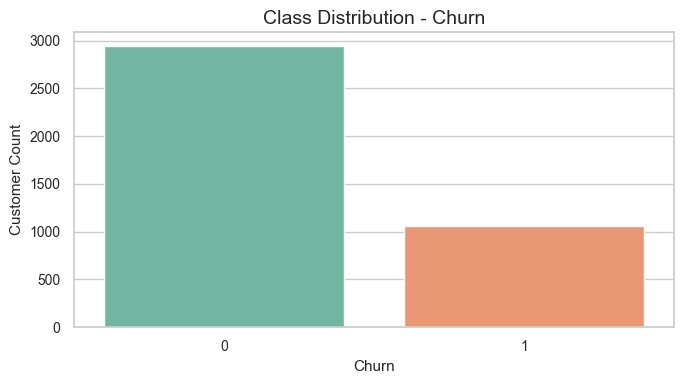

In [17]:
PROJECT_NAME = "Gym Customer Churn Prediction"
DATA_PATH_CANDIDATES = [
    Path(r"D:\UIT SUBJECTS\Nam 2 - hoc ki 2 - Machine Learning\DoAn - GymCustomers and Churn\Data\gym_churn_us.csv"),
    Path.cwd() / "Data" / "gym_churn_us.csv",
    Path.cwd().parent / "Data" / "gym_churn_us.csv",
]

DATA_PATH = next((path for path in DATA_PATH_CANDIDATES if path.exists()), DATA_PATH_CANDIDATES[0])

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found. Tried: {[str(path) for path in DATA_PATH_CANDIDATES]}")

PROJECT_ROOT = DATA_PATH.parent.parent
MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)

print(f"Project: {PROJECT_NAME}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Data path: {DATA_PATH}")
print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
display(df.head())

if TARGET_COL not in df.columns:
    raise KeyError(f"Target column '{TARGET_COL}' not found in dataset.")

class_distribution = pd.DataFrame({
    "count": df[TARGET_COL].value_counts().sort_index(),
    "percentage": (df[TARGET_COL].value_counts(normalize=True).sort_index() * 100).round(2),
})
display(class_distribution)

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x=TARGET_COL, palette="Set2")
plt.title("Class Distribution - Churn")
plt.xlabel("Churn")
plt.ylabel("Customer Count")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "baseline_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


# 04. Define Features

Define target và feature columns theo dataset gốc. Notebook này chỉ dùng dữ liệu gốc, không tạo feature engineering mới.


In [18]:
FEATURE_COLUMNS = [
    "gender",
    "Near_Location",
    "Partner",
    "Promo_friends",
    "Phone",
    "Contract_period",
    "Group_visits",
    "Age",
    "Avg_additional_charges_total",
    "Month_to_end_contract",
    "Lifetime",
    "Avg_class_frequency_total",
    "Avg_class_frequency_current_month",
]

missing_features = [col for col in FEATURE_COLUMNS if col not in df.columns]
if missing_features:
    print(f"Warning: missing feature columns will be skipped: {missing_features}")

feature_columns = [col for col in FEATURE_COLUMNS if col in df.columns]

X = df[feature_columns].copy()
y = df[TARGET_COL].copy()

print(f"Number of features: {len(feature_columns)}")
print("Features:", feature_columns)
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")


Number of features: 13
Features: ['gender', 'Near_Location', 'Partner', 'Promo_friends', 'Phone', 'Contract_period', 'Group_visits', 'Age', 'Avg_additional_charges_total', 'Month_to_end_contract', 'Lifetime', 'Avg_class_frequency_total', 'Avg_class_frequency_current_month']
X shape: (4000, 13)
y shape: (4000,)


# 05. Train-Test Split

Dùng stratified split để giữ tỷ lệ churn/non-churn giữa train và test set. Điều này quan trọng với churn prediction vì target thường không cân bằng hoàn toàn.


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"Train shape: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Test shape: X_test={X_test.shape}, y_test={y_test.shape}")

train_distribution = pd.DataFrame({
    "count": y_train.value_counts().sort_index(),
    "percentage": (y_train.value_counts(normalize=True).sort_index() * 100).round(2),
})
test_distribution = pd.DataFrame({
    "count": y_test.value_counts().sort_index(),
    "percentage": (y_test.value_counts(normalize=True).sort_index() * 100).round(2),
})

print("Train churn distribution:")
display(train_distribution)
print("Test churn distribution:")
display(test_distribution)


Train shape: X_train=(3200, 13), y_train=(3200,)
Test shape: X_test=(800, 13), y_test=(800,)
Train churn distribution:


,count,percentage
Churn,,
0,2351,73.4700
1,849,26.5300


Test churn distribution:


,count,percentage
Churn,,
0,588,73.5000
1,212,26.5000


# 06. Preprocessing

Dataset gần như đã numeric và không cần encoding phức tạp. Baseline notebook này chỉ dùng preprocessing tối thiểu: **StandardScaler** cho toàn bộ numeric features.

Scaling đặc biệt cần cho Logistic Regression, KNN và SVM. Tree-based models không bắt buộc scaling, nhưng dùng cùng pipeline giúp workflow nhất quán và dễ so sánh.


In [20]:
numeric_features = feature_columns.copy()

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_features),
    ],
    remainder="drop",
)

print("Numeric features used in preprocessing:")
print(numeric_features)


Numeric features used in preprocessing:
['gender', 'Near_Location', 'Partner', 'Promo_friends', 'Phone', 'Contract_period', 'Group_visits', 'Age', 'Avg_additional_charges_total', 'Month_to_end_contract', 'Lifetime', 'Avg_class_frequency_total', 'Avg_class_frequency_current_month']


# 07. Define Baseline Models

Define nhiều baseline models để so sánh từ linear model, distance-based model, tree model, ensemble model đến boosting model. Các model được giữ cấu hình đơn giản, chưa tuning chuyên sâu.


In [21]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "Extra Trees": ExtraTreesClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "AdaBoost": AdaBoostClassifier(random_state=RANDOM_STATE),
    "SVM (RBF)": SVC(probability=True, random_state=RANDOM_STATE),
}

if XGBClassifier is not None:
    models["XGBoost"] = XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE, verbosity=0)

if LGBMClassifier is not None:
    models["LightGBM"] = LGBMClassifier(random_state=RANDOM_STATE, verbose=-1)

if CatBoostClassifier is not None:
    models["CatBoost"] = CatBoostClassifier(verbose=0, random_state=RANDOM_STATE)

print(f"Number of baseline models: {len(models)}")
print(list(models.keys()))


Number of baseline models: 11
['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest', 'Extra Trees', 'Gradient Boosting', 'AdaBoost', 'SVM (RBF)', 'XGBoost', 'LightGBM', 'CatBoost']


# 08. Define Evaluation Function

Tạo helper functions để build pipeline, fit model, predict, lấy probability score và tính nhiều metrics. Trong churn prediction, ROC-AUC và F1 thường quan trọng hơn accuracy vì business cần nhận diện nhóm churn tốt hơn.


In [22]:
def build_model_pipeline(model):
    """Build a standard sklearn pipeline with preprocessing and classifier."""
    return Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model),
    ])


def get_positive_class_scores(pipeline, X_data):
    """Return score/probability for positive class when available."""
    if hasattr(pipeline, "predict_proba"):
        return pipeline.predict_proba(X_data)[:, 1]
    if hasattr(pipeline, "decision_function"):
        scores = pipeline.decision_function(X_data)
        return scores
    return None


def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    """Train a model pipeline and return test metrics plus trained pipeline."""
    pipeline = build_model_pipeline(model)
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_score = get_positive_class_scores(pipeline, X_test)

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, y_score) if y_score is not None else np.nan,
    }
    return metrics, pipeline


# 09. Train All Baseline Models

Train toàn bộ baseline models trên train set và đánh giá trên hold-out test set. Kết quả được sort theo ROC-AUC giảm dần, sau đó F1 giảm dần.


In [23]:
all_metrics = []
trained_pipelines = {}
failed_models = []

for name, model in models.items():
    print(f"Training {name}...")
    try:
        metrics, trained_pipeline = evaluate_model(name, model, X_train, X_test, y_train, y_test)
        all_metrics.append(metrics)
        trained_pipelines[name] = trained_pipeline
    except Exception as exc:
        failed_models.append({"Model": name, "Error": str(exc)})
        print(f"Warning: {name} failed and will be skipped. Error: {exc}")

results_df = pd.DataFrame(all_metrics).sort_values(["ROC_AUC", "F1"], ascending=False).reset_index(drop=True)

display(results_df.style.highlight_max(subset=["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"], color="#C8E6C9").format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1": "{:.4f}",
    "ROC_AUC": "{:.4f}",
}))

if failed_models:
    print("Failed models:")
    display(pd.DataFrame(failed_models))

best_model_name = results_df.iloc[0]["Model"]
best_pipeline = trained_pipelines[best_model_name]
print(f"Best baseline model by ROC-AUC: {best_model_name}")


Training Logistic Regression...
Training KNN...
Training Decision Tree...
Training Random Forest...
Training Extra Trees...
Training Gradient Boosting...
Training AdaBoost...
Training SVM (RBF)...
Training XGBoost...
Training LightGBM...
Training CatBoost...


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,CatBoost,0.9475,0.9167,0.8821,0.8990,0.9826
1,XGBoost,0.9450,0.9078,0.8821,0.8947,0.9800
2,LightGBM,0.9425,0.9150,0.8632,0.8883,0.9775
3,Logistic Regression,0.9250,0.8800,0.8302,0.8544,0.9774
4,Gradient Boosting,0.9437,0.9196,0.8632,0.8905,0.9774
5,SVM (RBF),0.9350,0.9040,0.8443,0.8732,0.9704
6,Random Forest,0.9250,0.8838,0.8255,0.8537,0.9684
7,AdaBoost,0.9163,0.8607,0.8160,0.8378,0.9653
8,Extra Trees,0.9137,0.8667,0.7972,0.8305,0.9579
9,KNN,0.8900,0.8100,0.7642,0.7864,0.9199


Best baseline model by ROC-AUC: CatBoost


# 10. Cross Validation

Hold-out test set cho biết performance trên một split cụ thể. Cross validation giúp đánh giá model ổn định hơn trên nhiều fold, đặc biệt khi muốn so sánh baseline models một cách công bằng hơn.


Cross-validating Logistic Regression...
Cross-validating Random Forest...
Cross-validating XGBoost...
Cross-validating CatBoost...


,Model,mean_accuracy,mean_precision,mean_recall,mean_f1,mean_roc_auc,std_roc_auc
0,CatBoost,0.9487,0.9255,0.8775,0.9008,0.9858,0.0045
1,XGBoost,0.9400,0.9078,0.8614,0.8840,0.9801,0.0043
2,Logistic Regression,0.9262,0.8819,0.8341,0.8571,0.9766,0.0039
3,Random Forest,0.9187,0.8733,0.8115,0.8411,0.9723,0.0048


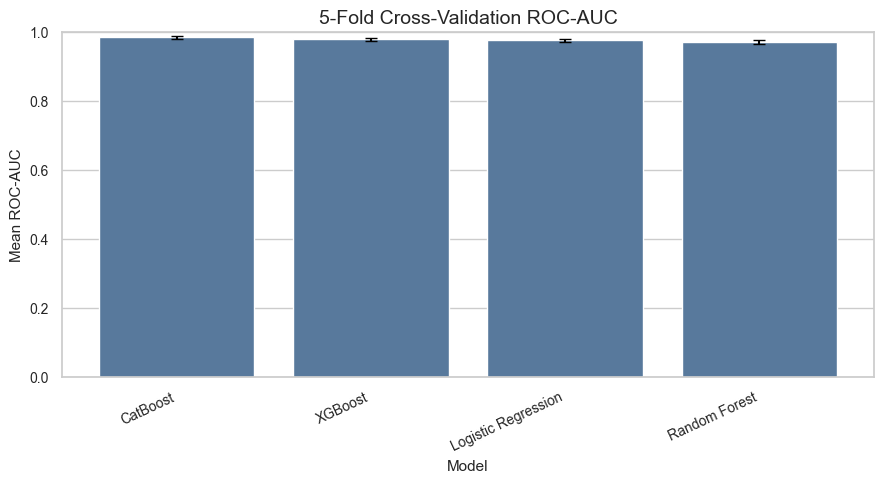

In [24]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}


def cross_validate_model(name, model, X, y):
    """Run stratified cross validation for one model."""
    pipeline = build_model_pipeline(model)
    cv_scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        error_score=np.nan,
    )
    return {
        "Model": name,
        "mean_accuracy": np.nanmean(cv_scores["test_accuracy"]),
        "mean_precision": np.nanmean(cv_scores["test_precision"]),
        "mean_recall": np.nanmean(cv_scores["test_recall"]),
        "mean_f1": np.nanmean(cv_scores["test_f1"]),
        "mean_roc_auc": np.nanmean(cv_scores["test_roc_auc"]),
        "std_roc_auc": np.nanstd(cv_scores["test_roc_auc"]),
    }

cv_model_names = ["Logistic Regression", "Random Forest", "XGBoost", "CatBoost"]
cv_results = []
for name in cv_model_names:
    if name in models:
        print(f"Cross-validating {name}...")
        try:
            cv_results.append(cross_validate_model(name, models[name], X, y))
        except Exception as exc:
            print(f"Warning: CV failed for {name}. Error: {exc}")
    else:
        print(f"Skipping {name}: model is not available in this environment.")

cv_results_df = pd.DataFrame(cv_results).sort_values("mean_roc_auc", ascending=False).reset_index(drop=True)
display(cv_results_df)

if not cv_results_df.empty:
    plt.figure(figsize=(9, 5))
    sns.barplot(data=cv_results_df, x="Model", y="mean_roc_auc", color="#4C78A8")
    plt.errorbar(
        x=np.arange(len(cv_results_df)),
        y=cv_results_df["mean_roc_auc"],
        yerr=cv_results_df["std_roc_auc"],
        fmt="none",
        c="black",
        capsize=4,
    )
    plt.title("5-Fold Cross-Validation ROC-AUC")
    plt.xlabel("Model")
    plt.ylabel("Mean ROC-AUC")
    plt.ylim(0, 1)
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "baseline_cv_roc_auc.png", dpi=150, bbox_inches="tight")
    plt.show()


# 11. Confusion Matrix Analysis

Phân tích confusion matrix cho Top 3 models theo ROC-AUC.

Trong churn prediction:
- **False Positive:** model dự đoán khách hàng sẽ churn nhưng thực tế không churn. Có thể gây tốn chi phí retention không cần thiết.
- **False Negative:** model dự đoán khách hàng không churn nhưng thực tế churn. Đây thường là lỗi nghiêm trọng hơn vì doanh nghiệp bỏ sót khách hàng sắp rời bỏ.
- **Recall class churn** quan trọng vì đo khả năng bắt đúng khách hàng churn.


Model: CatBoost
Classification report:


,precision,recall,f1-score,support
0,0.9581,0.9711,0.9645,588.0000
1,0.9167,0.8821,0.8990,212.0000
accuracy,0.9475,0.9475,0.9475,0.9475
macro avg,0.9374,0.9266,0.9318,800.0000
weighted avg,0.9471,0.9475,0.9472,800.0000


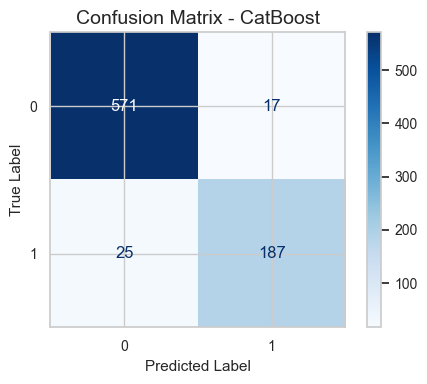

Model: XGBoost
Classification report:


,precision,recall,f1-score,support
0,0.9579,0.9677,0.9628,588.0000
1,0.9078,0.8821,0.8947,212.0000
accuracy,0.9450,0.9450,0.9450,0.9450
macro avg,0.9328,0.9249,0.9288,800.0000
weighted avg,0.9446,0.9450,0.9447,800.0000


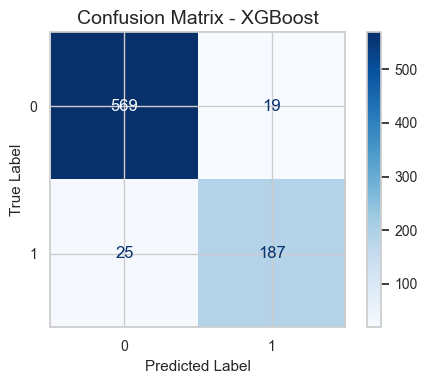

Model: LightGBM
Classification report:


,precision,recall,f1-score,support
0,0.9517,0.9711,0.9613,588.0000
1,0.9150,0.8632,0.8883,212.0000
accuracy,0.9425,0.9425,0.9425,0.9425
macro avg,0.9333,0.9171,0.9248,800.0000
weighted avg,0.9420,0.9425,0.9420,800.0000


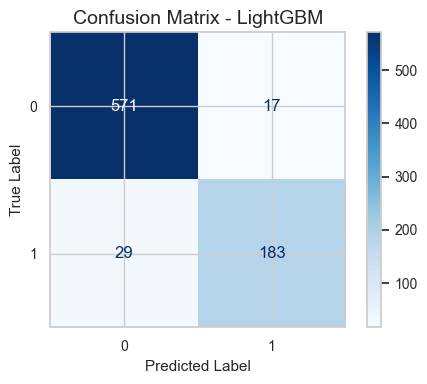

In [25]:
top3_model_names = results_df.head(3)["Model"].tolist()

for name in top3_model_names:
    pipeline = trained_pipelines[name]
    y_pred = pipeline.predict(X_test)

    print("=" * 80)
    print(f"Model: {name}")
    print("Classification report:")
    report_df = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True, zero_division=0)).T
    display(report_df)

    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues", ax=ax, values_format="d")
    ax.set_title(f"Confusion Matrix - {name}")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"baseline_confusion_matrix_{name.replace(' ', '_').replace('(', '').replace(')', '')}.png", dpi=150, bbox_inches="tight")
    plt.show()


# 12. ROC Curve Comparison

So sánh ROC curve cho một số model đại diện: Logistic Regression, RandomForest, XGBoost và CatBoost nếu available. ROC-AUC đo khả năng ranking khách churn cao hơn khách không churn trên nhiều threshold khác nhau.


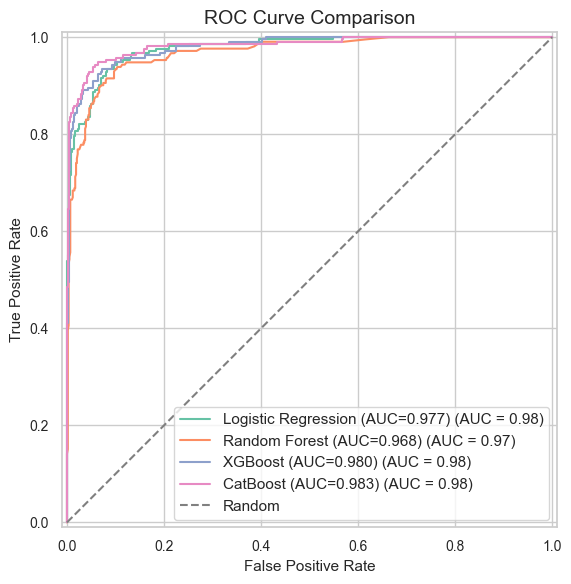

In [26]:
roc_model_names = ["Logistic Regression", "Random Forest", "XGBoost", "CatBoost"]

plt.figure(figsize=(8, 6))
ax = plt.gca()
for name in roc_model_names:
    if name not in trained_pipelines:
        print(f"Skipping ROC curve for {name}: model not trained or not available.")
        continue
    pipeline = trained_pipelines[name]
    y_score = get_positive_class_scores(pipeline, X_test)
    if y_score is None:
        print(f"Skipping ROC curve for {name}: no probability/score output.")
        continue
    auc_value = roc_auc_score(y_test, y_score)
    RocCurveDisplay.from_predictions(y_test, y_score, name=f"{name} (AUC={auc_value:.3f})", ax=ax)

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "baseline_roc_curve_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


# 13. Precision-Recall Curve

Precision-Recall curve quan trọng khi dataset có imbalance vì nó tập trung vào class dương, tức khách hàng churn. Với churn prediction, precision và recall giúp hiểu trade-off giữa bắt đúng khách churn và số lượng cảnh báo sai.


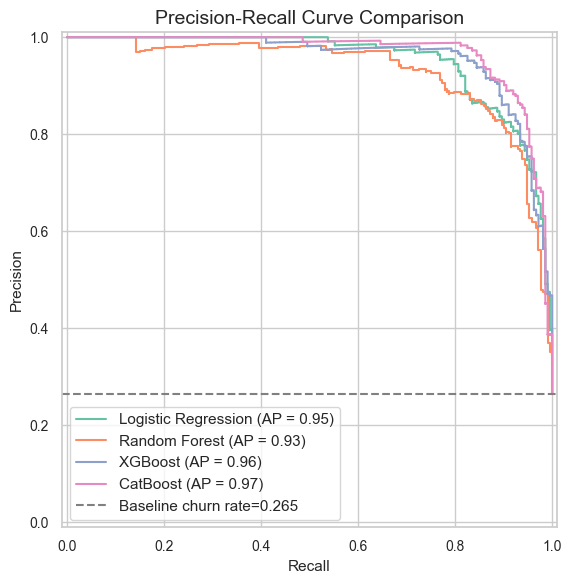

In [27]:
plt.figure(figsize=(8, 6))
ax = plt.gca()
for name in roc_model_names:
    if name not in trained_pipelines:
        print(f"Skipping PR curve for {name}: model not trained or not available.")
        continue
    pipeline = trained_pipelines[name]
    y_score = get_positive_class_scores(pipeline, X_test)
    if y_score is None:
        print(f"Skipping PR curve for {name}: no probability/score output.")
        continue
    PrecisionRecallDisplay.from_predictions(y_test, y_score, name=name, ax=ax)

baseline_churn_rate = y_test.mean()
plt.axhline(baseline_churn_rate, linestyle="--", color="gray", label=f"Baseline churn rate={baseline_churn_rate:.3f}")
plt.title("Precision-Recall Curve Comparison")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="best")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "baseline_precision_recall_curve_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


# 14. Feature Importance

Phân tích feature importance cho tree-based models có thuộc tính `feature_importances_`: RandomForest, XGBoost, LightGBM và CatBoost nếu available.

Feature importance giúp nhận diện tín hiệu dự đoán mạnh, nhưng cần diễn giải cẩn thận vì importance không chứng minh quan hệ nhân quả.


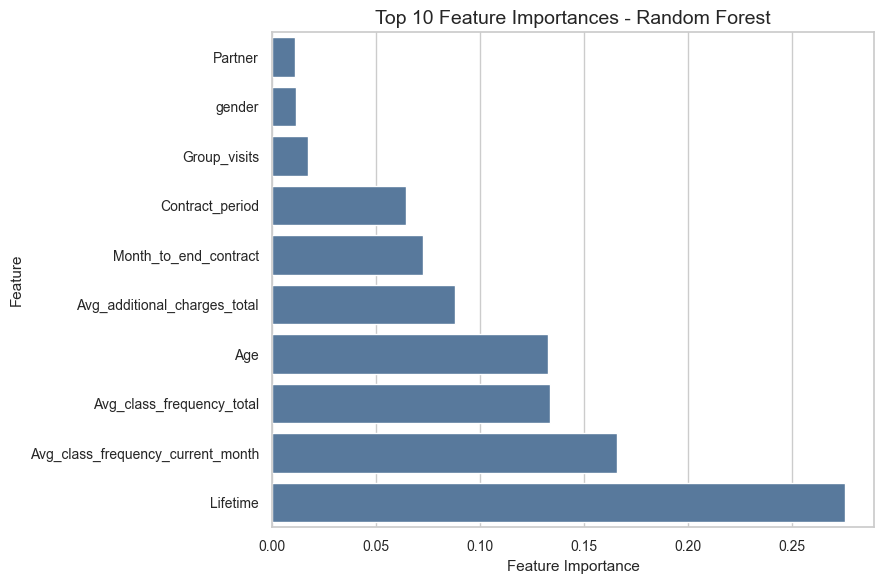

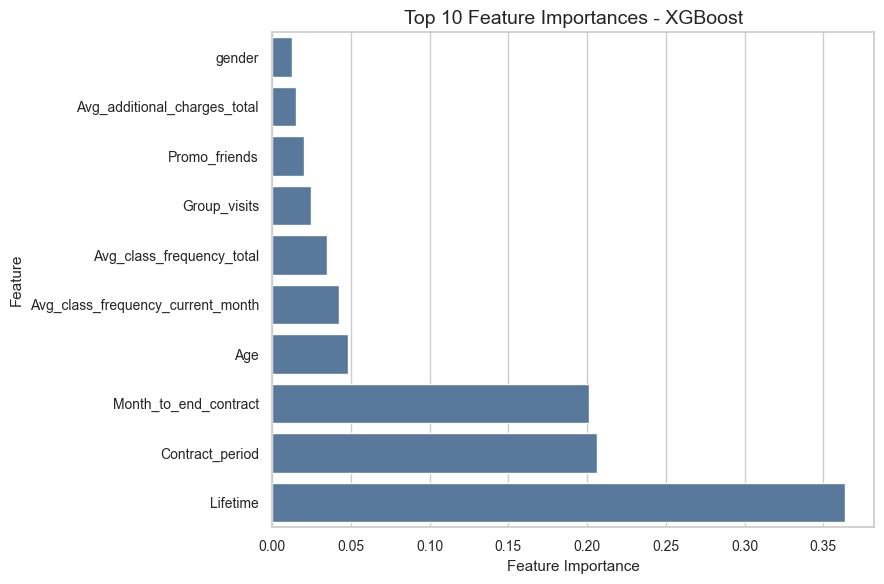

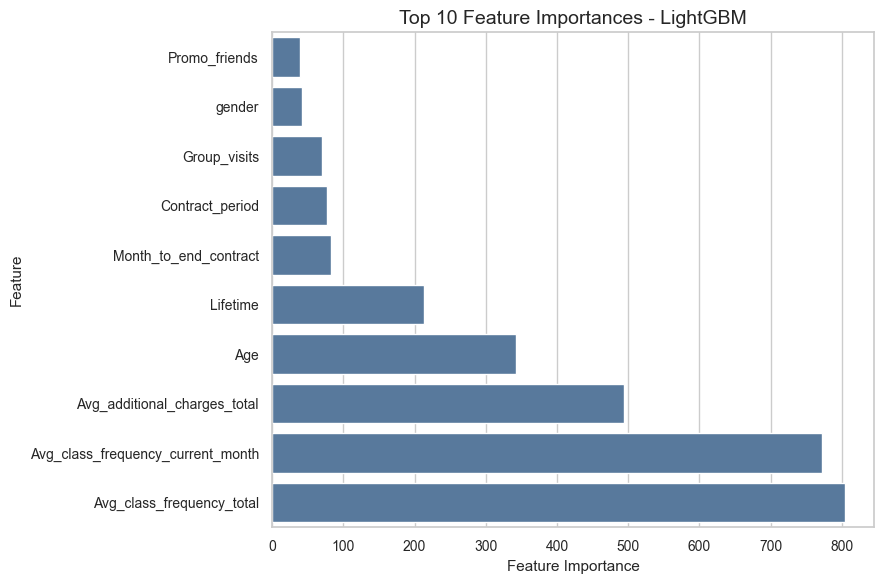

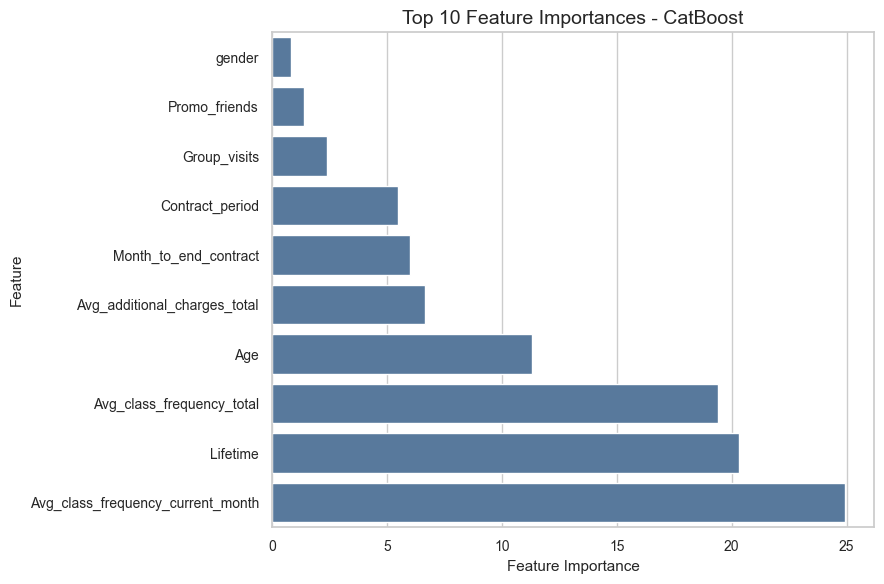

,Feature,Mean Importance
0,Avg_class_frequency_total,206.1391
1,Avg_class_frequency_current_month,199.2893
2,Avg_additional_charges_total,125.1838
3,Age,88.6249
4,Lifetime,58.4945
5,Month_to_end_contract,22.0717
6,Contract_period,20.6825
7,Group_visits,18.1130
8,gender,10.7082
9,Promo_friends,10.1072


In [28]:
def extract_feature_importance(pipeline, model_name, feature_names):
    """Extract feature_importances_ from a trained pipeline if available."""
    estimator = pipeline.named_steps["model"]
    if not hasattr(estimator, "feature_importances_"):
        return pd.DataFrame()
    importance = pd.DataFrame({
        "Model": model_name,
        "Feature": feature_names,
        "Importance": estimator.feature_importances_,
    }).sort_values("Importance", ascending=False)
    return importance

importance_model_names = ["Random Forest", "XGBoost", "LightGBM", "CatBoost"]
all_importance_tables = []

for name in importance_model_names:
    if name not in trained_pipelines:
        print(f"Skipping feature importance for {name}: model not trained or not available.")
        continue

    importance_df = extract_feature_importance(trained_pipelines[name], name, feature_columns)
    if importance_df.empty:
        print(f"Skipping feature importance for {name}: feature_importances_ not available.")
        continue

    all_importance_tables.append(importance_df)
    top10 = importance_df.head(10).sort_values("Importance", ascending=True)

    plt.figure(figsize=(9, 6))
    sns.barplot(data=top10, x="Importance", y="Feature", color="#4C78A8")
    plt.title(f"Top 10 Feature Importances - {name}")
    plt.xlabel("Feature Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"baseline_feature_importance_{name.replace(' ', '_')}.png", dpi=150, bbox_inches="tight")
    plt.show()

if all_importance_tables:
    feature_importance_all = pd.concat(all_importance_tables, ignore_index=True)
    display(feature_importance_all.groupby("Feature")["Importance"].mean().sort_values(ascending=False).reset_index().rename(columns={"Importance": "Mean Importance"}))
else:
    feature_importance_all = pd.DataFrame()
    print("No feature importance table available.")


# 15. Model Comparison Summary

Tổng hợp ranking baseline models và visualization so sánh Accuracy, F1, ROC-AUC. Model tốt nhất được chọn theo ROC-AUC, sau đó dùng F1 làm tiêu chí phụ.


,Rank,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,1,CatBoost,0.9475,0.9167,0.8821,0.8990,0.9826
1,2,XGBoost,0.9450,0.9078,0.8821,0.8947,0.9800
2,3,LightGBM,0.9425,0.9150,0.8632,0.8883,0.9775
3,4,Logistic Regression,0.9250,0.8800,0.8302,0.8544,0.9774
4,5,Gradient Boosting,0.9437,0.9196,0.8632,0.8905,0.9774
5,6,SVM (RBF),0.9350,0.9040,0.8443,0.8732,0.9704
6,7,Random Forest,0.9250,0.8838,0.8255,0.8537,0.9684
7,8,AdaBoost,0.9163,0.8607,0.8160,0.8378,0.9653
8,9,Extra Trees,0.9137,0.8667,0.7972,0.8305,0.9579
9,10,KNN,0.8900,0.8100,0.7642,0.7864,0.9199


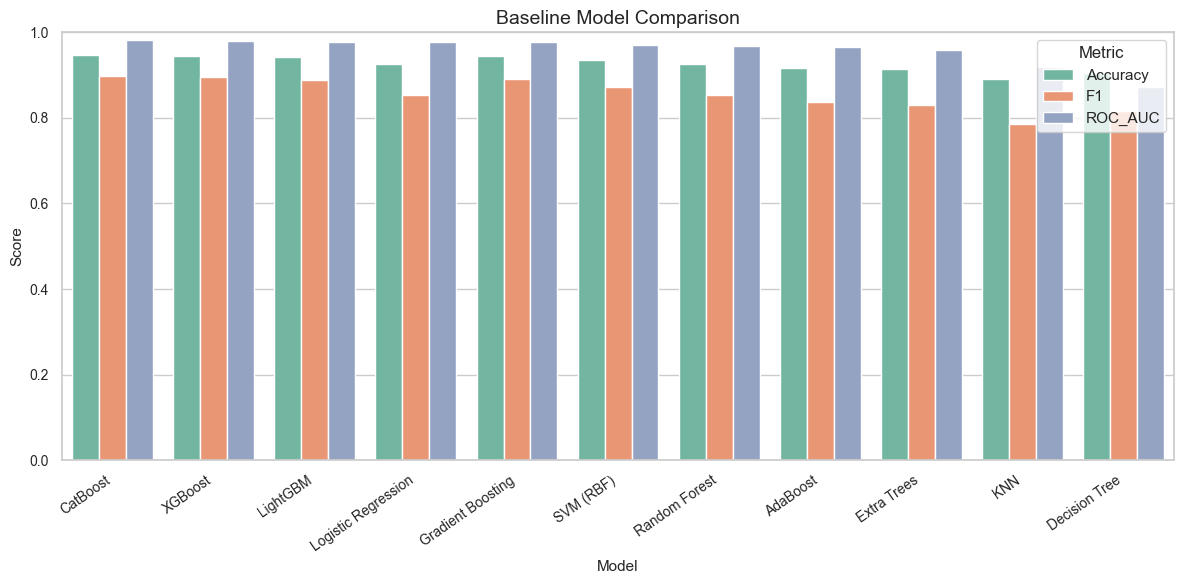

Best model: CatBoost
Best ROC-AUC: 0.9826
F1 of best model: 0.8990


In [29]:
model_ranking = results_df.copy()
model_ranking.insert(0, "Rank", np.arange(1, len(model_ranking) + 1))
display(model_ranking)

plot_metrics = ["Accuracy", "F1", "ROC_AUC"]
comparison_long = results_df.melt(id_vars="Model", value_vars=plot_metrics, var_name="Metric", value_name="Score")

plt.figure(figsize=(12, 6))
sns.barplot(data=comparison_long, x="Model", y="Score", hue="Metric", palette="Set2")
plt.title("Baseline Model Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=35, ha="right")
plt.legend(title="Metric")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "baseline_model_comparison_grouped_barplot.png", dpi=150, bbox_inches="tight")
plt.show()

best_row = results_df.iloc[0]
print(f"Best model: {best_row['Model']}")
print(f"Best ROC-AUC: {best_row['ROC_AUC']:.4f}")
print(f"F1 of best model: {best_row['F1']:.4f}")


# 16. Business Interpretation

Baseline modeling cho thấy model nào có thể phù hợp hơn tùy mục tiêu business:

- **Logistic Regression** dễ giải thích, phù hợp khi cần model đơn giản, minh bạch và dễ trình bày với stakeholder.
- **RandomForest / ExtraTrees** thường ổn định, bắt được nonlinear relationships, có feature importance trực quan.
- **XGBoost / LightGBM / CatBoost** thường mạnh về performance, đặc biệt với dữ liệu tabular, nhưng cần kiểm soát overfitting và giải thích bằng SHAP ở notebook sau.
- **KNN / SVM** có thể là baseline hữu ích nhưng thường kém thuận tiện hơn khi cần giải thích business hoặc scale lớn.

Trong churn prediction, model production không chỉ cần ROC-AUC cao. Doanh nghiệp cần cân nhắc thêm:
- Recall churn để giảm số khách churn bị bỏ sót.
- Precision để tránh lãng phí chi phí retention.
- Interpretability để đội business hiểu vì sao khách hàng bị đánh dấu rủi ro.
- Latency và khả năng vận hành nếu triển khai thực tế.


# 17. Save Best Model

Lưu best trained pipeline và bảng metrics để dùng lại ở các notebook tiếp theo. Pipeline bao gồm cả preprocessing và model.


In [30]:
best_model_path = MODELS_DIR / "best_baseline_model.pkl"
metrics_path = MODELS_DIR / "baseline_model_metrics.csv"

joblib.dump(best_pipeline, best_model_path)
results_df.to_csv(metrics_path, index=False)

print(f"Saved best baseline model to: {best_model_path}")
print(f"Saved baseline metrics to: {metrics_path}")


Saved best baseline model to: D:\UIT SUBJECTS\Nam 2 - hoc ki 2 - Machine Learning\DoAn - GymCustomers and Churn\models\best_baseline_model.pkl
Saved baseline metrics to: D:\UIT SUBJECTS\Nam 2 - hoc ki 2 - Machine Learning\DoAn - GymCustomers and Churn\models\baseline_model_metrics.csv


# 18. Final Conclusions

Notebook này đã xây dựng baseline workflow cho bài toán **Gym Customer Churn Prediction**:

- Đã train và so sánh nhiều baseline models trên cùng một train-test split.
- Đã đánh giá bằng Accuracy, Precision, Recall, F1 và ROC-AUC.
- Đã dùng cross validation cho một số model đại diện để đánh giá độ ổn định.
- Đã phân tích confusion matrix, ROC curve, Precision-Recall curve và feature importance.
- Đã lưu best baseline pipeline để tái sử dụng.

Các feature thường đáng chú ý trong bài toán churn này gồm:
- `Lifetime`
- `Avg_class_frequency_current_month`
- `Month_to_end_contract`
- `Contract_period`

Hạn chế hiện tại:
- Chưa feature engineering.
- Chưa xử lý imbalance nâng cao.
- Chưa tuning hyperparameters chuyên sâu.
- Chưa dùng explainability như SHAP.

Đề xuất notebook tiếp theo:
- Feature engineering dựa trên EDA và business hypotheses.
- Imbalance handling có kiểm soát.
- Hyperparameter tuning bằng RandomizedSearchCV hoặc Optuna.
- SHAP explainability cho model mạnh nhất.
- Chuẩn bị pipeline deployment nếu cần triển khai thực tế.
